In [1]:
from tqdm import tqdm

import numpy as np
import awkward as ak
import vector
vector.register_awkward()
import uproot

import mplhep as hep
hep.style.use('CMS')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Seeded Cone Python implementation

This is a “seeded cone” clustering algorithm, done event by event.
The particles argument should be an `Awkward` array of particles with `(pt, eta, phi)` fields
It returns a `Vector` of jets with fields `(pt, eta, phi)` and `constituents`. The `constituents` field are indices of the `particles` clustered to each jet.

In [2]:
def seeded_cone_exact(particles,
                       R: float = 0.4,
                       max_jets: int = 12, # Maximum number of jets based on PUPPI collection --> Make larger if larger PFCands collection
                       ) -> vector.Array:

    # --- Prepare per-particle kinematics
    pT = ak.fill_none(particles.pt, 0.0)
    eta = ak.fill_none(particles.eta, 0.0)
    phi = ak.fill_none(particles.phi, 0.0)

    out_jets = []
    n_events = len(particles)
    
    # --- Loop over events
    for ev in tqdm(range(n_events)):
        ev_pT = np.array(pT[ev].to_list())
        ev_eta = np.array(eta[ev].to_list())
        ev_phi = np.array(phi[ev].to_list())
        n = ev_pT.size
        # ...keeping track of clustered particles: remaining[i] includes particles not clustered into a jet yet.
        remaining = np.ones(n, dtype=bool)

        jets_ev = []

        # --- Loop over jets: build jets until you run out of particles or hit max_jets
        while remaining.any() and len(jets_ev) < max_jets:
            rem_indices = np.nonzero(remaining)[0]
            if rem_indices.size == 0:
                break
                
            # --- Define the seed as the highest pT remaining particle
            seed_idx = rem_indices[np.argmax(ev_pT[rem_indices])]

            # --- Find constituents within cone radius R around the seed: jet constituents are those within dR2 of the seed
            dr2 = (ev_eta[seed_idx] - ev_eta) ** 2 + (
                (ev_phi[seed_idx] - ev_phi + np.pi) % (2 * np.pi) - np.pi
            ) ** 2
            in_mask = (dr2 <= R * R) & remaining
            constituents = np.nonzero(in_mask)[0]

            # --- Compute jet axis as pT-weighted average: sum the pT and compute the (eta, phi) axis
            pT_cons = ev_pT[constituents]
            sum_pT = pT_cons.sum()
            if sum_pT <= 0:
                remaining[constituents] = False
                continue
            eta_jet = (pT_cons * ev_eta[constituents]).sum() / sum_pT
            cos_phi = (pT_cons * np.cos(ev_phi[constituents])).sum()
            sin_phi = (pT_cons * np.sin(ev_phi[constituents])).sum()
            phi_jet = np.arctan2(sin_phi, cos_phi)

            jets_ev.append({'pt'  : float(sum_pT),
                            'eta' : float(eta_jet),
                            'phi' : float(phi_jet),
                            'constituents' : constituents.tolist()})

            remaining[constituents] = False

        out_jets.append(jets_ev)
        
    jets_ak = ak.Array(out_jets)

    # --- Store the jet + list of constituent indices
    jets_vec = vector.zip({
        "pt": ak.values_astype(jets_ak["pt"], np.float64),
        "eta": ak.values_astype(jets_ak["eta"], np.float64),
        "phi": ak.values_astype(jets_ak["phi"], np.float64),
    })

    jets_vec = ak.with_field(jets_vec, jets_ak["constituents"], "constituents")
    return jets_vec

## Utilities for evaluating matching

The `match_jets` function matches jets between two collections event-by-event using closest ΔR.

It returns an Awkward array where each jet of `jets1` has fields:
- `j1` - the jet
- `j2` - the best matched jet from `jets2`
- `deltaR` - the dR between `j1` and `j2`
- `unmatched` - the properties of the jet if it doesn't have a good match

`compute_residuals` function returns the distance between these pairs in pT, eta, phi, and deltaR

In [3]:
def match_jets(jets1, jets2, dR_max=0.4):
    """
    Match jets2 to jets1 per event by closest ΔR.
    Returns an awkward array with fields: j1, j2, deltaR, unmatched
    """

    # --- Build all jet pairs within each event and compute ΔR for each pair using vector
    pairs = ak.cartesian({"j1": jets1, "j2": jets2}, axis=1, nested=True)
    dR = pairs["j1"].deltaR(pairs["j2"])

    best_idx = ak.argmin(dR, axis=-1, keepdims=True)

    matched_j2 = pairs["j2"][best_idx]
    matched_dR = dR[best_idx]

    mask = matched_dR < dR_max

    matched_j1   = ak.mask(jets1, mask)
    unmatched_j1 = ak.mask(jets1, ~mask)
    matched_j2   = ak.mask(matched_j2, mask)
    matched_dR   = ak.mask(matched_dR, mask)

    return ak.zip({
        "j1": matched_j1,
        "j2": matched_j2,
        "deltaR": matched_dR,
        "unmatched": unmatched_j1,
    })

## Example

Example based on a `perfNano.root` ntuple from FastPuppi, with a `L1PuppiCands` collection (which is made similar to a `L1PFCands` by removing cuts after application of the PUPPI weights) and a `scPuppiJets` collection. 

Different collections could be used for either the particles or reference jets, as long as they have `(pt, eta, phi)` fields.

In [4]:
with uproot.open("/eos/cms/store/cmst3/group/l1tr/elfontan/l1tPFplusPuppi/fp_ntuples_151X_targetStudies/TT_PU200/FP/151Xv0/perfNano_16676705_126.root") as file:
    tree = file["Events"]
    particles = ak.zip({
        "pt": tree["L1PuppiCands_pt"].array(),
        "eta": tree["L1PuppiCands_eta"].array(),
        "phi": tree["L1PuppiCands_phi"].array()
    })
    ref_jets = vector.zip({
        "pt": tree["scPuppiJets_pt"].array(),
        "eta": tree["scPuppiJets_eta"].array(),
        "phi": tree["scPuppiJets_phi"].array()
    })
   
    newJets_sc = seeded_cone_exact(particles, R=0.4, max_jets=12)

100%|██████████| 2000/2000 [00:01<00:00, 1473.10it/s]


In [5]:
def compute_residuals(matches):
    j1 = ak.drop_none(matches["j1"])
    j2 = ak.drop_none(matches["j2"])

    return {
        "pt": ak.to_numpy(ak.flatten((j1.pt - j2.pt) / j2.pt, axis=None)),
        "eta": ak.to_numpy(ak.flatten(j1.eta - j2.eta, axis=None)),
        "phi": ak.to_numpy(ak.flatten(j1.deltaphi(j2), axis=None)),
        "deltaR": ak.to_numpy(ak.flatten(j1.deltaR(j2), axis=None)),
    }

## Evaluate

First perform matching and plot the residuals

In [6]:
matches_py_ref = match_jets(newJets_sc, ref_jets, dR_max=0.4)

res_py_ref = compute_residuals(matches_py_ref)

[]

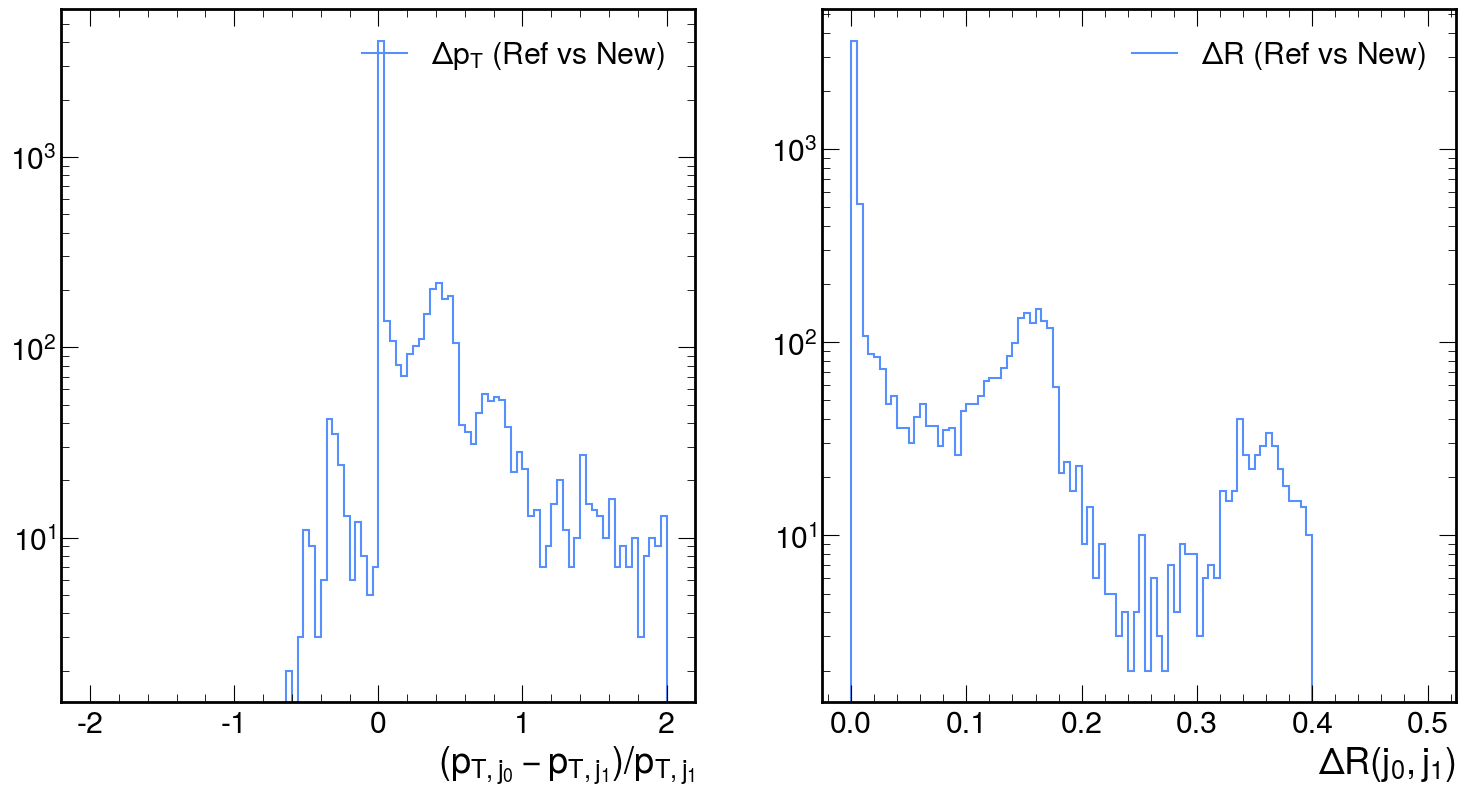

In [7]:
pt_bins = np.linspace(-2, 2, 101)
dR_bins = np.linspace(0, 0.5, 101)
f, axs = plt.subplots(1, 2, figsize=(18, 9))

h, _ = np.histogram(res_py_ref['pt'], bins=pt_bins)
hep.histplot(h, pt_bins, label=r'$\Delta p_T$ (Ref vs New)', ax=axs[0])
    
h, _ = np.histogram(res_py_ref['deltaR'], bins=dR_bins)
hep.histplot(h, dR_bins, label=r'$\Delta R$ (Ref vs New)', ax=axs[1])
    
axs[0].set_xlabel(r'($p_{T, j_0} - p_{T, j_1}) / p_{T, j_1}$')
axs[1].set_xlabel(r'$\Delta R (j_0, j_1)$')
axs[0].legend()
axs[1].legend()
axs[0].semilogy()
axs[1].semilogy()

## Event display

For some extra visual validation, make an event display of the two jet collections and the constituents.

The `event_display` function makes an η–φ plot for one event:

- draws circles of radius R around jet axes (CMSSW vs Python)
- scatters constituents of each Python jet (size ~ pT)
- scatters leftover unclustered particles in gray
- handles φ wrap-around by drawing a second circle when close to ±π

In [8]:
def event_display(particles, jets_ref, jets_new, R=0.4, event_idx=0):
    """
    Plot an event display of the jets and constituents for some visual validation
    particles: awkward Array with fields (pt, eta, phi)
    jets_ref: vector.Array (jets from exact algorithm)
    jets_new: vector.Array (jets with new PUPPI weights)
    event_idx: which event to plot
    """

    # Get event-level data
    p_eta = ak.to_numpy(particles[event_idx].eta)
    p_phi = ak.to_numpy(particles[event_idx].phi)
    p_pt  = ak.to_numpy(particles[event_idx].pt)

    j_eta_ref = ak.to_numpy(jets_ref[event_idx].eta)
    j_phi_ref = ak.to_numpy(jets_ref[event_idx].phi)

    j_eta_new = ak.to_numpy(jets_new[event_idx].eta)
    j_phi_new = ak.to_numpy(jets_new[event_idx].phi)

    fig, ax = plt.subplots(figsize=(7,6))

    def add_circle(e, p, R, edgecolor, linestyle, label):
        circ = mpatches.Circle((e, p), radius=R, fill=False, linestyle=linestyle,
                               edgecolor=edgecolor, linewidth=2, alpha=0.8, label=label)
        ax.add_patch(circ)        
        # add another circle at the pi boundary if close to the edge
        if (np.pi - np.abs(p)) < 0.4:
            p_wrap = p - 2 * np.pi if p > 0 else p + 2 * np.pi
            circ = mpatches.Circle((e, p_wrap), radius=R, fill=False, linestyle=linestyle,
                                   edgecolor=edgecolor, linewidth=2, alpha=0.8, label=label)
            ax.add_patch(circ)  
    
    # REF seeded-cone jets as open circles
    for e, p in zip(j_eta_ref, j_phi_ref):
        add_circle(e, p, R, "C0", "-", "Ref (scPuppiJets)")
        #add_circle(e, p, R, "C0", "-", "CMSSW jet")
 
    # NEW seeded-cone jets as open circles
    for e, p in zip(j_eta_new, j_phi_new):
        add_circle(e, p, R, "C1", "--", "New PUPPI jets")
        #add_circle(e, p, R, "C1", "--", "Py jet")

    # Jet constituents as points
    for j, _ in enumerate(jets_new[event_idx]):
        constituent_idxs = jets_new[event_idx][j].constituents
        constituents = particles[event_idx][constituent_idxs]
        # size is pT * 3 : a fudge factor to make them reasonably sized
        ax.scatter(constituents.eta, constituents.phi,
                   s=constituents.pt * 3, alpha=0.3, color=f"C{j%10}")
        
    # Unclustered particles as points
    # get the indices of any particles not included in a jet
    # jets constituents are expected to be exclusive
    unclustered_idx = list(set(list(range(len(particles[event_idx])))) - set(ak.ravel(jets_new[event_idx].constituents)))
    unclustered = particles[event_idx][unclustered_idx]
    ax.scatter(unclustered.eta, unclustered.phi,
               s=unclustered.pt * 3, alpha=0.3, color=f"grey")    
    
    ax.set_xlim((-5, +5))
    ax.set_ylim((-np.pi, np.pi))
    ax.set_xlabel(r"$\eta$")
    ax.set_ylabel(r"$\phi$")

    # Deduplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc="best")
    ax.set_aspect('equal')

    plt.show()


len(particles): 2000
len(ref_jets): 2000
len(newJets_sc): 2000


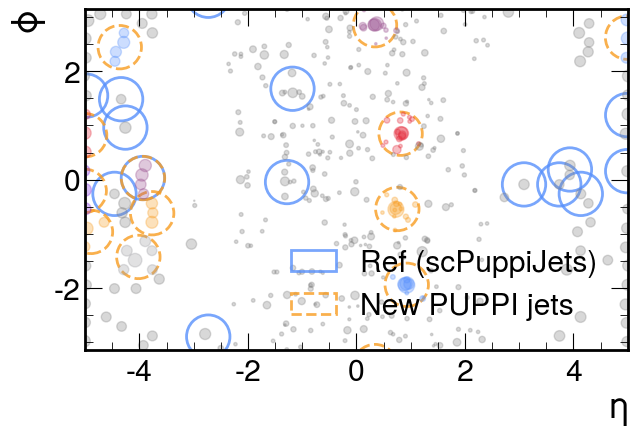

In [9]:
print("len(particles):", len(particles))
print("len(ref_jets):", len(ref_jets))
print("len(newJets_sc):", len(newJets_sc))
#print("type(newJets_sc):", type(newJets_sc))
#print("newJets_sc.type:", newJets_sc.type)

event_display(particles, ref_jets, newJets_sc, event_idx=1)